# ABN

In [1]:
from IPython.display import HTML

#HTML('''<script>
#code_show=true; 
#function code_toggle() {
# if (code_show){
# $('div.input').hide();
# } else {
# $('div.input').show();
# }
# code_show = !code_show
#} 
#$( document ).ready(code_toggle);
#</script>
#<form action="javascript:code_toggle()"><input type="submit" value="Click here to toggle on/off the raw code."></form>''')

## Import libraries

In [2]:
import time,os,datetime,math,warnings
import pandas as pd
import numpy as np
import scipy as sp
from scipy import interpolate
import scipy.optimize as optimize
import matplotlib.pyplot as plt
import pandas_datareader as web
import statsmodels.api as sm
import statsmodels.formula.api as reg
from statsmodels.tsa import tsatools
from statsmodels.tsa.vector_ar.var_model  import VAR
import subprocess as sub
from sklearn.decomposition import PCA
from scipy.interpolate import interp1d

#matplotlib.rcdefaults()


warnings.filterwarnings('ignore')
freq='Q'
pd.core.common.is_list_like = pd.api.types.is_list_like
pd.options.display.float_format = '{:,.4f}'.format
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
draft_path = ""


## Read and process macrodata
We download macrodata from FRED. The frequency is **quarterly**. Things can be aggregated to annual frequency if needed. We extract data on output, inflation, and several items of the goverment accounts from NIPA. The data is stored in "macrodata". 

In [4]:
Sim_data = pd.read_csv("../Data/Sim_other_series.csv")
fama_portfolio = pd.read_csv('../Data/Sim_data.csv')
start_year = 1678
macrodata = pd.DataFrame(np.ones(len(Sim_data)))
macrodata.index = pd.date_range(start=datetime.date(start_year, 1, 1),
                                periods=len(Sim_data),
                                freq="Q")
Sim_data = Sim_data.set_index(macrodata.index.copy())
Sim_data.describe()
end_year = macrodata.index.year[-1]
macrodata.index

#macrodata=web.DataReader(["GDP","GDP"], "fred",start,end).resample(freq).mean()
#macrodata.columns = ["gdp_nominal","TB3"]
#start = datetime.date(start_year,6,1)
#fama_portfolio = pd.read_csv('Sim_data.csv')
macrodata['TB3'] = fama_portfolio["1"].values * 4 * 100
macrodata['cons']=1

# define inflation as rate of change of CPI
macrodata['inflation']=0
rho_pi=0
macrodata['inf_innov']=0
pi_bar=1.0

# definte a measure of output. Here we start with real GDP

macrodata['real_gdp'] = Sim_data["GDP"]

macrodata['gdp_nominal'] = Sim_data["GDP"]

# Define terms for computing the primary deficits relative to output
# spending
macrodata['g'] = Sim_data["g"]
macrodata['real_g'] = Sim_data["g"]
macrodata['real_g_y']=macrodata['real_g']/macrodata['real_gdp']
macrodata['real_g_y']=macrodata['real_g_y']*100
#macrodata['real_g_y']=macrodata['real_g']/macrodata['real_gdp']
macrodata['g_y']=macrodata['real_g_y']

# revenues
macrodata['real_R'] = Sim_data["Revenue"]
macrodata['R'] = Sim_data["Revenue"]
macrodata['real_R_y']=macrodata['real_R']/macrodata['real_gdp']
macrodata['real_R_y']=macrodata['real_R_y']*100
macrodata['R_y']=macrodata['real_R_y']


macrodata['real_deficits'] = Sim_data["Primary_def"]
macrodata['deficits'] = Sim_data["Primary_def"]

cycle, trend = sm.tsa.filters.hpfilter(macrodata['real_deficits'], 1600)
macrodata['real_deficits_hp']=cycle
macrodata['real_deficits_hptrend']=trend

cycle, trend = sm.tsa.filters.hpfilter(macrodata['deficits'], 1600)
macrodata['deficits_hp']=cycle
macrodata['deficits_hptrend']=trend
#macrodata['deficits_dt'] = sm.tsa.detrend(macrodata['deficits'], order=1)


macrodata['real_deficits_y']=macrodata['real_g_y']-macrodata['real_R_y']
macrodata['real_deficits_y_dm']=macrodata['real_deficits_y']-macrodata['real_deficits_y'].mean()


macrodata['deficits_y']=macrodata['g_y']-macrodata['R_y']
macrodata['deficits_y_dm']=macrodata['deficits_y']-macrodata['deficits_y'].mean()

# expost and ex-ante real risk-free rate
macrodata['expost_rf'] = macrodata.TB3/4

macrodata['exante_rf'] = macrodata.TB3/4
macrodata['rf'] = macrodata.TB3/4
macrodata['nom_shortrate']=macrodata.TB3/4

#S=pd.read_csv('S.csv')
#start_S=datetime.date(1985,12,31)
#end_S = datetime.date(2017,12,31)


#S.set_index(pd.date_range(start=start_S,end=end_S,freq='Q'),inplace=True)

#macrodata['S']=S.S

return_data=pd.read_csv('../Data/crsp_return_data.csv')
return_data_start=datetime.date(1950,1,31)
return_data_end = datetime.date(2020,12,31)
return_data.set_index(pd.date_range(start=return_data_start,end=return_data_end,freq='M'),inplace=True)
market_return=return_data['sprtrn'].resample('Q').sum()
macrodata['market_return']=market_return*100
#macrodata['S']=
#lpdata=pd.read_csv('lpdata.csv')
#lpdata.index=pd.date_range(datetime.date(1984,3,31),datetime.date(2020,6,30),freq='Q')
#tbdata=pd.read_csv('tbdata.csv')
#tbdata.index=pd.date_range(datetime.date(1961,6,30),datetime.date(2020,9,30),freq='Q')


,g,Revenue,Primary_def,GDP,tax
count,264.0000,264.0000,264.0000,264.0000,264.0000
mean,0.1544,0.1885,-0.0342,1.0412,0.1810
std,0.0086,0.0011,0.0075,0.0060,0.0000
min,0.1353,0.1861,-0.0508,1.0279,0.1810
25%,0.1483,0.1877,-0.0394,1.0370,0.1810
50%,0.1552,0.1886,-0.0334,1.0418,0.1810
75%,0.1588,0.1891,-0.0303,1.0444,0.1810
max,0.1780,0.1915,-0.0135,1.0579,0.1810


DatetimeIndex(['1678-03-31', '1678-06-30', '1678-09-30', '1678-12-31',
               '1679-03-31', '1679-06-30', '1679-09-30', '1679-12-31',
               '1680-03-31', '1680-06-30',
               ...
               '1741-09-30', '1741-12-31', '1742-03-31', '1742-06-30',
               '1742-09-30', '1742-12-31', '1743-03-31', '1743-06-30',
               '1743-09-30', '1743-12-31'],
              dtype='datetime64[ns]', length=264, freq='Q-DEC')

In [5]:
macrodata[["g_y",'real_g_y',"real_R_y","deficits_y","R_y"]].describe()

,g_y,real_g_y,real_R_y,deficits_y,R_y
count,264.0000,264.0000,264.0000,264.0000,264.0000
mean,14.8199,14.8199,18.1043,-3.2844,18.1043
std,0.7339,0.7339,0.0000,0.7339,0.0000
min,13.1662,13.1662,18.1043,-4.9381,18.1043
25%,14.3008,14.3008,18.1043,-3.8036,18.1043
50%,14.8998,14.8998,18.1043,-3.2045,18.1043
75%,15.2075,15.2075,18.1043,-2.8968,18.1043
max,16.8305,16.8305,18.1043,-1.2738,18.1043


### Description of the timeseries related to terms in the government budget constraint

#### Real Governemnt Spending (Federal)
To construct expenditures we use the quarterly series of Federal Consumption Expenditures + Federal TransferPaymentsToPersons deflated by GDP deflator

<Figure size 640x480 with 0 Axes>

<Axes: >

<Axes: title={'center': 'real govt. spending'}>

<Axes: >

<Axes: title={'center': 'spending by GDP'}>

count   264.0000
mean     14.8199
std       0.7339
min      13.1662
25%      14.3008
50%      14.8998
75%      15.2075
max      16.8305
Name: real_g_y, dtype: float64

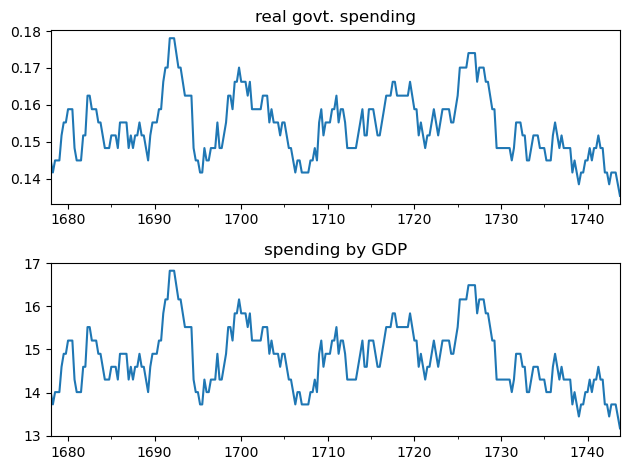

In [6]:
plt.figure(1)
plt.subplot(2,1,1)
macrodata['real_g'].plot(title='real govt. spending');#no need to specify for first axis
plt.subplot(2,1,2)
macrodata['real_g_y'].plot(ax=plt.gca(),title='spending by GDP');
plt.tight_layout()
macrodata['real_g_y'].describe()

<Figure size 640x480 with 0 Axes>

<Axes: >

<Axes: title={'center': 'nominal govt. spending'}>

<Axes: >

<Axes: title={'center': 'spending by GDP'}>

count   264.0000
mean     14.8199
std       0.7339
min      13.1662
25%      14.3008
50%      14.8998
75%      15.2075
max      16.8305
Name: g_y, dtype: float64

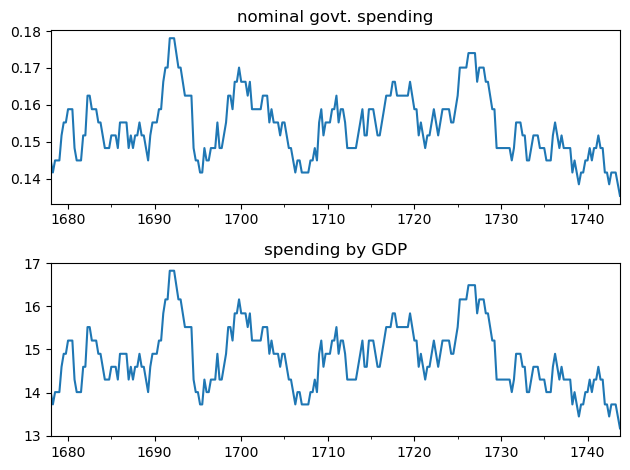

In [7]:
plt.figure(1)
plt.subplot(2,1,1)
macrodata['g'].plot(title='nominal govt. spending');#no need to specify for first axis
plt.subplot(2,1,2)
macrodata['g_y'].plot(ax=plt.gca(),title='spending by GDP');
plt.tight_layout()
macrodata['g_y'].describe()

### Detrended Nominal Governemnt Spending (Federal)
We extract a linear trend from log nominal spending

<Figure size 640x480 with 0 Axes>

<Axes: >

<Axes: title={'center': 'nominal govt. spending'}>

<Axes: >

<Axes: title={'center': 'nominal govt. spending detrended'}>

count   264.0000
mean     -0.0000
std       5.4084
min     -11.4146
25%      -4.0001
50%      -0.4543
75%       3.5634
max      13.5372
Name: ln_g_dt, dtype: float64

0.9061579935155751

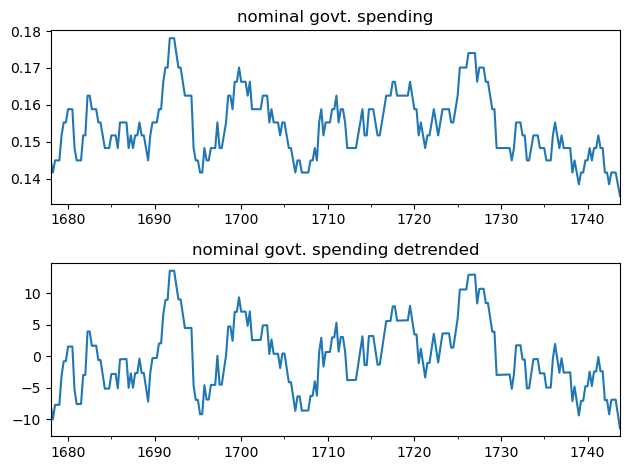

In [8]:
detrended_ln_g = sm.tsa.detrend(np.log(macrodata['g']), order=1)

macrodata['ln_g_dt']=detrended_ln_g *100
plt.figure(1)
plt.subplot(2,1,1)
macrodata['g'].plot(title='nominal govt. spending');#no need to specify for first axis
plt.subplot(2,1,2)
macrodata['ln_g_dt'].plot(ax=plt.gca(),title='nominal govt. spending detrended');
plt.tight_layout()

macrodata['ln_g_dt'].describe()
macrodata['ln_g_dt'].autocorr()

#### Governemnt Nominal  Revenues (Federal)
We construct Revenues as  Nominal Federal TotalCurrentTaxReceipts +Federal'ContributionToSocialInsurance'

<Figure size 640x480 with 0 Axes>

<Axes: >

<Axes: title={'center': 'nominal govt. revenues'}>

<Axes: >

<Axes: title={'center': 'revenues by GDP'}>

count   264.0000
mean     18.1043
std       0.0000
min      18.1043
25%      18.1043
50%      18.1043
75%      18.1043
max      18.1043
Name: R_y, dtype: float64

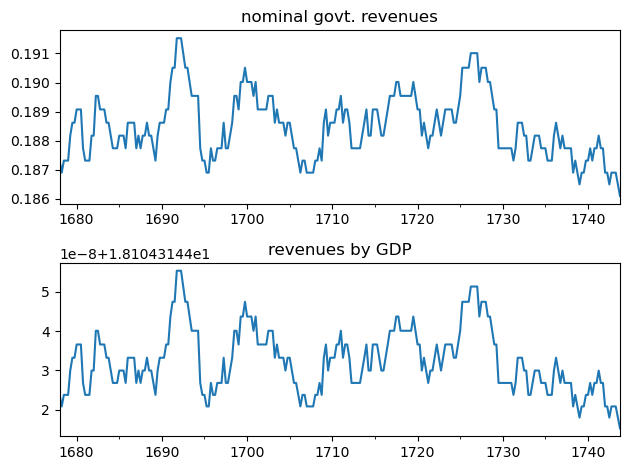

In [9]:
plt.figure(1)
plt.subplot(2,1,1)
macrodata['R'].plot(title='nominal govt. revenues');#no need to specify for first axis
plt.subplot(2,1,2)
macrodata['R_y'].plot(ax=plt.gca(),title='revenues by GDP');
plt.tight_layout()

macrodata['R_y'].describe()

#### Nominal Primary deficit (Federal)
We construct Deficits are defined expenditures minus revenues.

<Figure size 640x480 with 0 Axes>

<Axes: >

<Axes: title={'center': 'real primary deficits'}>

<Axes: >

<Axes: title={'center': 'deficits by GDP'}>

count   264.0000
mean     -3.2844
std       0.7339
min      -4.9381
25%      -3.8036
50%      -3.2045
75%      -2.8968
max      -1.2738
Name: deficits_y, dtype: float64

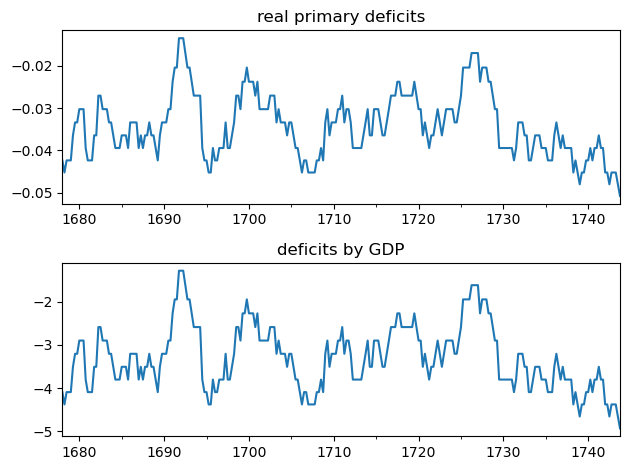

In [10]:
plt.figure(1)
plt.subplot(2,1,1)
macrodata['deficits'].plot(title='real primary deficits');#no need to specify for first axis
plt.subplot(2,1,2)
macrodata['deficits_y'].plot(ax=plt.gca(),title='deficits by GDP');
plt.tight_layout()

macrodata['deficits_y'].describe()

### Constructing $\frac{X_t}{\overline{y}_t}$

In this section, we construct a series for deficits relative to output trend. 

The deficits are divided by a seriers $\overline{y}_t$ that is simply the trend in GDP extracted by assuming a constant growth in logs, that is, $\overline{y_t}$ satisfies

$$ \log\text{real_gdp}_t =\underbrace{g_y t+\log y_0}_{\log{\overline{y}_t}}+ \log{\text{ deviations from trend}_t} $$


#### Output trend $\overline{y}_t$

<Axes: >

Growth rate per quarter % = -0.0012212102545392843


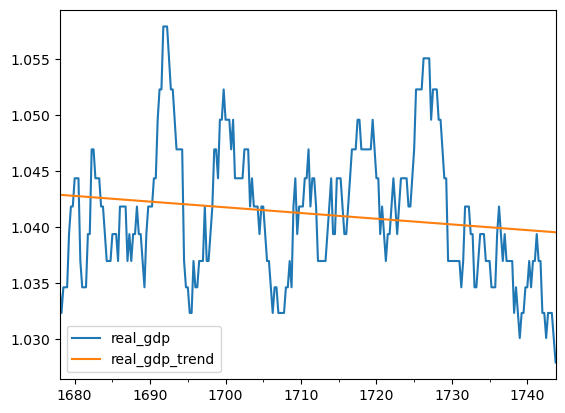

In [11]:
detrended_log_gdp = sm.tsa.detrend(np.log(macrodata['real_gdp']), order=1)
#detrended_log_gdp.plot()
log_trend=np.log(macrodata['real_gdp'])-detrended_log_gdp
y_trend=np.exp(log_trend)
macrodata['real_gdp_trend']=y_trend
macrodata['ln_real_gdp_dt']=detrended_log_gdp
gy=(log_trend-log_trend.shift()).mean()

#gy =0.0
macrodata[['real_gdp','real_gdp_trend']].plot()

print('Growth rate per quarter % = ' + str(gy*100))


<Axes: >

Growth rate per quarter % = -0.0012212102545392843


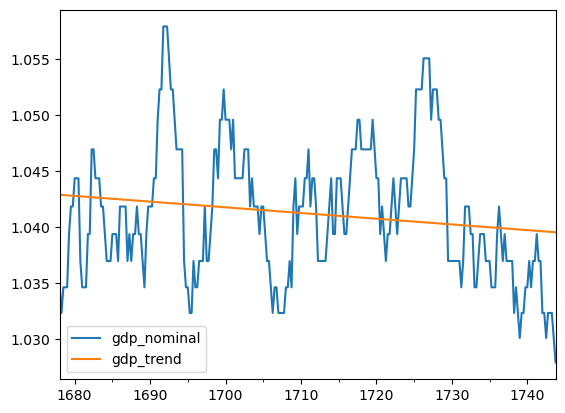

In [12]:
detrended_log_gdp = sm.tsa.detrend(np.log(macrodata['gdp_nominal']), order=1)
#detrended_log_gdp.plot()
log_trend=np.log(macrodata['gdp_nominal'])-detrended_log_gdp
y_trend=np.exp(log_trend)
macrodata['gdp_trend']=y_trend
macrodata['ln_gdp_dt']=detrended_log_gdp
gy=(log_trend-log_trend.shift()).mean()

#gy =0.0
macrodata[['gdp_nominal','gdp_trend']].plot()
print('Growth rate per quarter % = ' + str(gy*100))


#### Constructed series for  $\frac{X_t}{\overline{y}_t}$

<Axes: >

,deficits_y,deficits_dt
count,264.0000,264.0000
mean,-3.2844,-3.2803
std,0.7339,0.7175
min,-4.9381,-4.8829
25%,-3.8036,-3.7917
50%,-3.2045,-3.2101
75%,-2.8968,-2.9027
max,-1.2738,-1.2930


,deficits_y,deficits_dt
deficits_y,1.0000,1.0000
deficits_dt,1.0000,1.0000


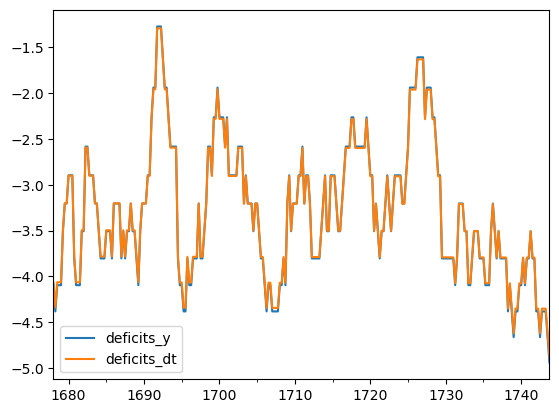

In [13]:
macrodata['deficits_dt']=(macrodata['deficits']/y_trend)*100
macrodata['deficits_dt_dm']=macrodata['deficits_dt']-macrodata['deficits_dt'].mean()
macrodata[['deficits_y','deficits_dt']].plot()
macrodata[['deficits_y','deficits_dt']].describe()
macrodata[['deficits_y','deficits_dt']].corr()

### Data  on tax rates (from Barro Redlick)
We take away the trend using a HP filter

<Axes: >

tau_alt   NaN
tau       NaN
dtype: float64

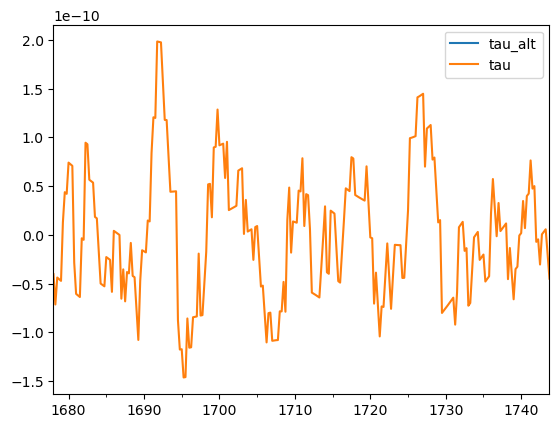

In [15]:
taxdata=pd.DataFrame()
taxdata["tau"] = pd.read_csv('../Data/Sim_other_series.csv')['tax']
taxdata.set_index(macrodata.index.copy(), inplace=True)


temp = taxdata


cycle, trend = sm.tsa.filters.hpfilter(temp.tau,100000)
temp["cycle"] = cycle
temp["trend"] = trend

macrodata['tau_raw']=temp['cycle']+temp["trend"]
macrodata['tau']=temp.cycle+taxdata['tau'].mean()
macrodata['tau_alt']=macrodata['tau_raw'].values
macrodata.loc[macrodata.index.year<1975,'tau_alt']=np.nan
(macrodata[['tau_alt','tau']]-macrodata[['tau_alt','tau']].mean()).plot()
macrodata[macrodata.index.year>1974][['tau_alt','tau']].std()

#### detreded TFP 
We construct the detreded TFP $\hat{\theta}_t$ using the expression

$$ \hat{\theta}_t = \widehat{\log(Y)}_t - \gamma \log(1-\overline{\tau}_{t})

<Axes: >

count   264.0000
mean      9.9862
std       0.5679
min       8.8624
25%       9.5637
50%       9.9254
75%      10.3446
max      11.4852
Name: theta, dtype: float64

0.9081978944780859

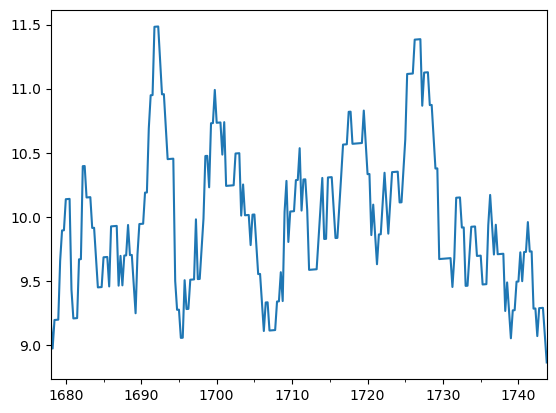

In [16]:
tau_bar=macrodata.tau.mean()
gamma=0.5

macrodata['theta']=macrodata['ln_gdp_dt'] -gamma*np.log(1-macrodata['tau'])


macrodata['theta']=macrodata['theta']*100
macrodata['theta'].plot()
macrodata['theta'].describe()
macrodata['theta'].autocorr()


In [19]:
# pd.concat({'Treasuries': treas_yields.T, 'HQM': hqmY.T}).T.to_csv('Yield_table_.csv', float_format='%.2f')

# pd.concat({'Treasuries': treas_yields.T, 'HQM': hqmY.T}).T

#### Read data for inflation

## Bond returns

This is the decription from CRSP: The Fama Maturity Portfolios are defined in 6-month intervals (TREASNOX range 2000028–2000037) and in 12-month intervals (TREASNOX range 2000040–2000044) for up to 60 months. TREASNOX 2000038 is a single portfolio for maturities between 60 and 120 months, and TREASNOX 2000039 is a single portfolio for maturities greater than 120 months. Each TREASNOX represents the portfolio containing one-month holding period returns for issues maturing in a range of months from the quote date. Callable, non-callable, and non-flower notes and bonds are included in the portfolios. Partially and full tax-exempt issues are excluded. The returns are calculated as the equal-weighted average of the unadjusted holding period return (TMRETNUA) for each bond in the portfolio. For our analysis we use hprXX where $XX  \in \{1,2,3,4,5, 510\}$ are maturities. 



In [20]:
def get_returns_ff(key,var_name,fama_portfolio):
    long_return=pd.DataFrame([fama_portfolio[fama_portfolio['KYTREASNOX']==key]['TMEWRETD'].values])
    long_return=long_return.T
    long_return['qdate'] = pd.date_range('1952-01-31',periods = len(long_return), freq='M')
    long_return.set_index('qdate',inplace=True)
    long_return.columns=[var_name]
    return pd.DataFrame(long_return.resample(freq).sum())*100

def adjust_real_hpr(n,inflation):
    inflation=inflation-inflation.mean()
    rho_pi=inflation.autocorr()
    factor=( (rho_pi/(1-rho_pi) )* (1-rho_pi**(n-1)) )* (inflation.shift(-1)-rho_pi*inflation)
    return factor




def construct_real_excess_returns(n,hpr,nom_rate):
    hprx=(hpr-nom_rate)
    #maturity=n*((freq=='A')*1.0+(freq=='Q')*4.0)
    # hprx=hprx+adjust_real_hpr(maturity,macrodata.inflation)
    return hprx
    

### Inflation adjustment 
In our baseline we want to use the real excess holding period return on nominal bonds. Since the inflation term will be in both the return on long bond and the risk-free rate, it will be cancelled. So no inflation adjustment is necessary

# Loading Simulated data

In [23]:
fama_portfolio = pd.read_csv('../Data/Sim_data.csv')
fama_portfolio = fama_portfolio.set_index(macrodata['nom_shortrate'].index.copy())
fama_portfolio = fama_portfolio*100
nom_returns = pd.DataFrame(macrodata['nom_shortrate'])
return_list = []
for mat in range(6, 66, 6):
    ret = fama_portfolio["{}".format(int(mat/3))]
    nom_returns['hprx'+str(mat)+'m'] = pd.DataFrame(macrodata['nom_shortrate'])
    nom_returns['hprx'+str(mat)+'m'][:] = ret[:]
    macrodata['hprx'+str(mat)+'m'] = construct_real_excess_returns(mat /
                                                                   12.0, ret, macrodata['nom_shortrate'])
    return_list.append('hprx'+str(mat)+'m')
    
hpr510yr = fama_portfolio["30"][:]

macrodata['hprx510yr'] = construct_real_excess_returns(
    7.5, hpr510yr, macrodata['nom_shortrate'])
nom_returns['hprx40Q'] = pd.DataFrame(macrodata['nom_shortrate'])
nom_returns['hprx40Q'][:] = hpr510yr[:]

hpr10plusyr = fama_portfolio["60"][:]
macrodata['hprx10plusyr'] = construct_real_excess_returns(
    15.0, hpr10plusyr, macrodata['nom_shortrate'])


macrodata['rf_lag'] = macrodata['rf'].shift()
return_list.append('hprx510yr')
return_list.append('hprx10plusyr')


#col_rename_dict = {i: j for i, j in zip(nom_returns.columns, yields_mat)}
#nom_returns.rename(columns=col_rename_dict, inplace=True)


#### Constructing Table

In [24]:
col_rename_dict = {i: j for i, j in zip(nom_returns.columns, ['{}m'.format(3*k) for k in np.hstack((np.hstack(([1], [j for j in range(2, 21, 2)])),40))])}
nom_returns.rename(columns=col_rename_dict, inplace=True)



#### Time series for returns

array([[<Axes: >, <Axes: >],
       [<Axes: >, <Axes: >],
       [<Axes: >, <Axes: >],
       [<Axes: >, <Axes: >],
       [<Axes: >, <Axes: >],
       [<Axes: >, <Axes: >]], dtype=object)

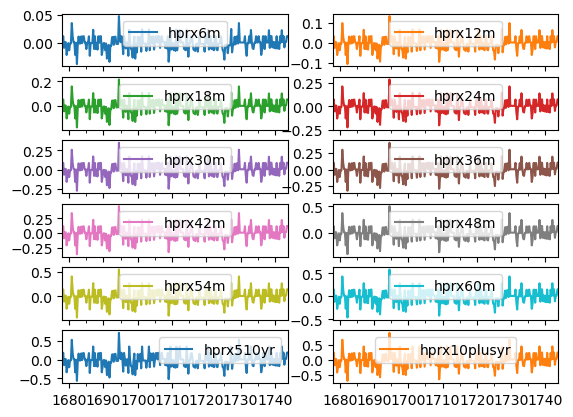

In [25]:
macrodata[return_list].plot(subplots=True,layout=(6,2))

#### Construct the first principal component of returns + rfrate + macrofactors

# For macrofactors I use deficits/gdp and detreded log gdp


explained variation
[0.7719149]


<Axes: >

sigma2_f
0.5469181770817264


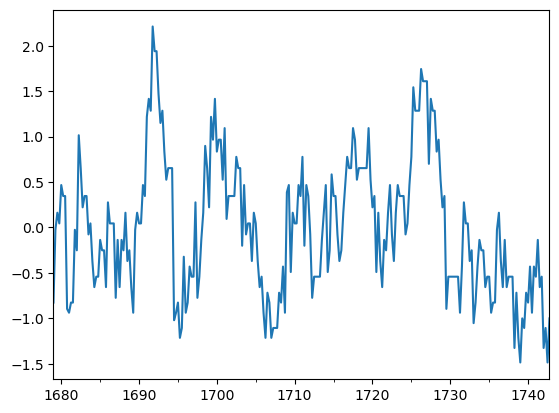

In [26]:
data=macrodata[(macrodata.index.year>start_year)&(macrodata.index.year<end_year) ]

#factornamelist=return_list+ ['deficits_y','nom_shortrate','log_gdp_dt']

factornamelist =['deficits_y','nom_shortrate','ln_real_gdp_dt'] + return_list

pca = PCA(n_components=1)
principalComponents = pca.fit_transform(data[factornamelist])
pair_of_return=return_list[:-1]

print ("explained variation")
print (pca.explained_variance_ratio_)

data['factor']=principalComponents
data['factor'].plot()
print ("sigma2_f")
print (data['factor'].var())
macrodata['factor']=data.factor

In [27]:
macrodata[return_list+['deficits_y']].describe().T

,count,mean,std,min,25%,50%,75%,max
hprx6m,264.0000,-0.0004,0.0123,-0.0378,-0.0091,-0.0006,0.0109,0.0475
hprx12m,264.0000,-0.0012,0.0350,-0.1076,-0.0260,-0.0017,0.0310,0.1354
hprx18m,264.0000,-0.0020,0.0554,-0.1702,-0.0414,-0.0028,0.0487,0.2143
hprx24m,264.0000,-0.0026,0.0737,-0.2264,-0.0555,-0.0038,0.0646,0.2853
hprx30m,264.0000,-0.0033,0.0902,-0.2769,-0.0684,-0.0047,0.0787,0.3492
hprx36m,264.0000,-0.0038,0.1051,-0.3222,-0.0801,-0.0056,0.0912,0.4066
hprx42m,264.0000,-0.0044,0.1184,-0.3629,-0.0907,-0.0064,0.1025,0.4583
hprx48m,264.0000,-0.0048,0.1305,-0.3995,-0.1004,-0.0071,0.1125,0.5049
hprx54m,264.0000,-0.0053,0.1413,-0.4325,-0.1092,-0.0078,0.1215,0.5468
hprx60m,264.0000,-0.0057,0.1511,-0.4621,-0.1171,-0.0084,0.1295,0.5845


## Summary Statistics for returns and deficits (detrended)

In [28]:
macrodata[return_list+['deficits_y']].describe().T

,count,mean,std,min,25%,50%,75%,max
hprx6m,264.0000,-0.0004,0.0123,-0.0378,-0.0091,-0.0006,0.0109,0.0475
hprx12m,264.0000,-0.0012,0.0350,-0.1076,-0.0260,-0.0017,0.0310,0.1354
hprx18m,264.0000,-0.0020,0.0554,-0.1702,-0.0414,-0.0028,0.0487,0.2143
hprx24m,264.0000,-0.0026,0.0737,-0.2264,-0.0555,-0.0038,0.0646,0.2853
hprx30m,264.0000,-0.0033,0.0902,-0.2769,-0.0684,-0.0047,0.0787,0.3492
hprx36m,264.0000,-0.0038,0.1051,-0.3222,-0.0801,-0.0056,0.0912,0.4066
hprx42m,264.0000,-0.0044,0.1184,-0.3629,-0.0907,-0.0064,0.1025,0.4583
hprx48m,264.0000,-0.0048,0.1305,-0.3995,-0.1004,-0.0071,0.1125,0.5049
hprx54m,264.0000,-0.0053,0.1413,-0.4325,-0.1092,-0.0078,0.1215,0.5468
hprx60m,264.0000,-0.0057,0.1511,-0.4621,-0.1171,-0.0084,0.1295,0.5845


#### Covariances of returns and deficits

In [30]:
variables = ['deficits_dt', 'tau']
#macrodata = macrodata.join(lpdata_yields_interpolated)
#macrodata['Yield_3m']=0

In [31]:
macrodata[return_list[0:-1]+variables].cov()

,hprx6m,hprx12m,hprx18m,hprx24m,hprx30m,hprx36m,hprx42m,hprx48m,hprx54m,hprx60m,hprx510yr,deficits_dt,tau
hprx6m,0.0002,0.0004,0.0007,0.0009,0.0011,0.0013,0.0015,0.0016,0.0017,0.0019,0.0023,-0.0030,-0.0000
hprx12m,0.0004,0.0012,0.0019,0.0026,0.0032,0.0037,0.0041,0.0046,0.0049,0.0053,0.0065,-0.0087,-0.0000
hprx18m,0.0007,0.0019,0.0031,0.0041,0.0050,0.0058,0.0066,0.0072,0.0078,0.0084,0.0104,-0.0137,-0.0000
hprx24m,0.0009,0.0026,0.0041,0.0054,0.0066,0.0077,0.0087,0.0096,0.0104,0.0111,0.0138,-0.0183,-0.0000
hprx30m,0.0011,0.0032,0.0050,0.0066,0.0081,0.0095,0.0107,0.0118,0.0127,0.0136,0.0169,-0.0223,-0.0000
hprx36m,0.0013,0.0037,0.0058,0.0077,0.0095,0.0110,0.0124,0.0137,0.0148,0.0159,0.0197,-0.0260,-0.0000
hprx42m,0.0015,0.0041,0.0066,0.0087,0.0107,0.0124,0.0140,0.0155,0.0167,0.0179,0.0222,-0.0293,-0.0000
hprx48m,0.0016,0.0046,0.0072,0.0096,0.0118,0.0137,0.0155,0.0170,0.0184,0.0197,0.0244,-0.0323,-0.0000
hprx54m,0.0017,0.0049,0.0078,0.0104,0.0127,0.0148,0.0167,0.0184,0.0200,0.0213,0.0264,-0.0350,-0.0000
hprx60m,0.0019,0.0053,0.0084,0.0111,0.0136,0.0159,0.0179,0.0197,0.0213,0.0228,0.0283,-0.0374,-0.0000


In [33]:
rescal_mat = macrodata[return_list[0:-1]+variables]
rescal_mat['tau'] = rescal_mat['tau']*100
rescal_mat['surplus'] = -rescal_mat['deficits_dt']

#rescal_mat['Yield_3m'] = rescal_mat['Yield_3m']
cov_mat = rescal_mat.cov()
cov_mat.where(np.triu(np.ones(cov_mat.shape)).astype(bool)).to_csv(
    draft_path+'covariances_returns_deficits_simulated_data.csv', float_format='%.2g')
cov_mat.where(np.triu(np.ones(cov_mat.shape)).astype(bool))


,hprx6m,hprx12m,hprx18m,hprx24m,hprx30m,hprx36m,hprx42m,hprx48m,hprx54m,hprx60m,hprx510yr,deficits_dt,tau,surplus
hprx6m,0.0002,0.0004,0.0007,0.0009,0.0011,0.0013,0.0015,0.0016,0.0017,0.0019,0.0023,-0.0030,-0.0000,0.0030
hprx12m,NaN,0.0012,0.0019,0.0026,0.0032,0.0037,0.0041,0.0046,0.0049,0.0053,0.0065,-0.0087,-0.0000,0.0087
hprx18m,NaN,NaN,0.0031,0.0041,0.0050,0.0058,0.0066,0.0072,0.0078,0.0084,0.0104,-0.0137,-0.0000,0.0137
hprx24m,NaN,NaN,NaN,0.0054,0.0066,0.0077,0.0087,0.0096,0.0104,0.0111,0.0138,-0.0183,-0.0000,0.0183
hprx30m,NaN,NaN,NaN,NaN,0.0081,0.0095,0.0107,0.0118,0.0127,0.0136,0.0169,-0.0223,-0.0000,0.0223
hprx36m,NaN,NaN,NaN,NaN,NaN,0.0110,0.0124,0.0137,0.0148,0.0159,0.0197,-0.0260,-0.0000,0.0260
hprx42m,NaN,NaN,NaN,NaN,NaN,NaN,0.0140,0.0155,0.0167,0.0179,0.0222,-0.0293,-0.0000,0.0293
hprx48m,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0170,0.0184,0.0197,0.0244,-0.0323,-0.0000,0.0323
hprx54m,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0200,0.0213,0.0264,-0.0350,-0.0000,0.0350
hprx60m,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0228,0.0283,-0.0374,-0.0000,0.0374


#### Autocorrelations

In [34]:
pd.DataFrame(rescal_mat.apply(lambda x: x.autocorr())).T.to_csv(
    'autocorr_sim_data.csv', float_format='%.2g')
pd.DataFrame(rescal_mat.apply(lambda x: x.autocorr())).T


,hprx6m,hprx12m,hprx18m,hprx24m,hprx30m,hprx36m,hprx42m,hprx48m,hprx54m,hprx60m,hprx510yr,deficits_dt,tau,surplus
0,-0.0243,-0.0246,-0.0249,-0.0251,-0.0253,-0.0255,-0.0257,-0.0258,-0.0260,-0.0261,-0.0266,0.9108,0.8675,0.9108


#### Means

In [35]:
pd.DataFrame(rescal_mat.mean()).T.to_csv(
    'means_no_adj_inflation_simulated_data.csv', float_format='%.2g')
pd.DataFrame(rescal_mat.mean()).T


,hprx6m,hprx12m,hprx18m,hprx24m,hprx30m,hprx36m,hprx42m,hprx48m,hprx54m,hprx60m,hprx510yr,deficits_dt,tau,surplus
0,-0.0004,-0.0012,-0.0020,-0.0026,-0.0033,-0.0038,-0.0044,-0.0048,-0.0053,-0.0057,-0.0072,-3.2803,18.1043,3.2803
